# Проект для компании "Тревэл Элевен"

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
table_TravelEleven = '/content/drive/MyDrive/Иннополис/Анализ решений/Проект/TravelEleven.csv'
df = pd.read_csv(table_TravelEleven, sep=';')

# Первичная обработка данных

Переводим дату в необходимый формат

In [7]:
df['start_session'] = pd.to_datetime(df['start_session'])
df['stop_session'] = pd.to_datetime(df['stop_session'])

## Средняя длительность сессии

In [8]:
df['session_duration'] = (df['stop_session'] - df['start_session']).dt.total_seconds() / 60
avg_session_duration = df['session_duration'].mean()
print(f"Средняя длительность сессии: {avg_session_duration:.2f} минут")

Средняя длительность сессии: 444.74 минут


## Средняя длительность сессии по сезонам

In [9]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Зима'
    elif month in [3, 4, 5]:
        return 'Весна'
    elif month in [6, 7, 8]:
        return 'Лето'
    else:
        return 'Осень'
df['month'] = df['start_session'].dt.month
df['season'] = df['month'].apply(get_season)

seasonal_duration = df.groupby('season')['session_duration'].mean()
print("Средняя длительность сессии по сезонам:")
print(seasonal_duration.round(2))

Средняя длительность сессии по сезонам:
season
Весна    1302.54
Зима      247.92
Лето     2995.03
Осень    1366.01
Name: session_duration, dtype: float64


## Спрос на туры по месяцам

In [10]:
monthly_demand = df.groupby(df['start_session'].dt.month).size()
print("Спрос на туры по месяцам:")
print(monthly_demand)

Спрос на туры по месяцам:
start_session
1     2442
2       60
3       98
4       68
5        1
6      107
7        6
10      57
11      15
12      27
dtype: int64


## Пиковые даты спроса на туры

In [11]:
daily_demand = df.groupby(df['start_session'].dt.date).size()
peak_days_tours = daily_demand.nlargest(5)
print(f"5 пиковых дней по спросу на туры:")
print(peak_days_tours)

5 пиковых дней по спросу на туры:
start_session
2024-01-12    107
2024-01-26    107
2024-01-08     95
2024-01-27     94
2024-01-14     92
dtype: int64


## Пиковые даты спроса на консультации

In [12]:
consultation_demand = df[df['consultation'] == True].groupby(df['start_session'].dt.date).size()
peak_days_consult = consultation_demand.nlargest(5)
print(f"5 пиковых дней по спросу на консультации:")
print(peak_days_consult)

5 пиковых дней по спросу на консультации:
start_session
2024-07-01    5
2024-02-03    4
2024-02-10    4
2024-03-07    4
2024-04-03    4
dtype: int64


## Страницы, с которых чаще всего обращаются за консультациями

In [13]:
consultation_pages = df[df['consultation'] == True]['website_page'].value_counts()
most_common_page = consultation_pages.index[0]
print(f"Чаще всего за консультацией обращаются со страницы: '{most_common_page}'")
print("Распределение по страницам:")
print(consultation_pages)

Чаще всего за консультацией обращаются со страницы: 'Search'
Распределение по страницам:
website_page
Search        44
Directions    39
Home          34
Sales         32
Order         28
About Us      26
Name: count, dtype: int64


## Доля самостоятельно оформляемых туров по страницам

In [14]:
self_service_rate = df[df['consultation'] == False].groupby('website_page').size() / df.groupby('website_page').size()
print("Доля самостоятельных оформлений по страницам:")
print(self_service_rate.round(3))

Доля самостоятельных оформлений по страницам:
website_page
About Us      0.944
Directions    0.922
Home          0.928
Order         0.942
Sales         0.935
Search        0.907
dtype: float64


## Популярные страны по сезонам

In [15]:
seasonal_countries = df.groupby(['season', 'travel_country']).size().groupby('season').nlargest(1)
print("Самые популярные страны по сезонам:")
for season in df['season'].unique():
    top_country = df[df['season'] == season]['travel_country'].mode()[0]
    print(f"{season}: {top_country}")

Самые популярные страны по сезонам:
Зима: Italy
Весна: Kazakhstan
Лето: Italy
Осень: Maldives


## Стоимость туров по направлениям

In [16]:
avg_price_by_country = df.groupby('travel_country')['travel_amount'].mean().sort_values(ascending=False)
print("Средняя стоимость тура по направлениям:")
print(avg_price_by_country.round(2))

Средняя стоимость тура по направлениям:
travel_country
Thailand                436451.02
Georgia                 430160.24
Italy                   373038.11
United Arab Emirates    357884.50
Dominican Republic      309265.06
Turkey                  308278.03
Egypt                   246917.15
Kazakhstan              176507.37
Maldives                171638.09
Russia                  107496.95
Name: travel_amount, dtype: float64


## Среднее количество человек по направлениям

In [17]:
avg_travelers_by_country = df.groupby('travel_country')['number_of_travalers'].mean().sort_values(ascending=False)
print("Среднее количество человек в туре по направлениям:")
print(avg_travelers_by_country.round(2))

Среднее количество человек в туре по направлениям:
travel_country
Russia                  3.14
Thailand                3.02
Maldives                3.01
Turkey                  3.00
Dominican Republic      2.97
Kazakhstan              2.93
Italy                   2.88
Egypt                   2.87
Georgia                 2.86
United Arab Emirates    2.85
Name: number_of_travalers, dtype: float64


##Доп анализ

In [18]:
gender_purchases = df['sex'].value_counts()
male_ratio = gender_purchases.get('Male', 0) / len(df)
female_ratio = gender_purchases.get('Female', 0) / len(df)
print(f"Распределение покупок по полу:")
print(f"Мужчины: {male_ratio:.1%}")
print(f"Женщины: {female_ratio:.1%}")

consultation_rate = df['consultation'].mean() * 100
print(f"Процент клиентов, воспользовавшихся консультацией: {consultation_rate:.1f}%")

avg_consult_duration = df[df['consultation'] == True]['cons_duration (min)'].mean()
print(f"Средняя длительность консультации: {avg_consult_duration:.1f} минут")

correlation = df['number_of_travalers'].corr(df['travel_amount'])
print(f"Корреляция между количеством людей и стоимостью тура: {correlation:.3f}")

Распределение покупок по полу:
Мужчины: 50.1%
Женщины: 49.9%
Процент клиентов, воспользовавшихся консультацией: 7.0%
Средняя длительность консультации: 82.3 минут
Корреляция между количеством людей и стоимостью тура: 0.737


## Визуализация

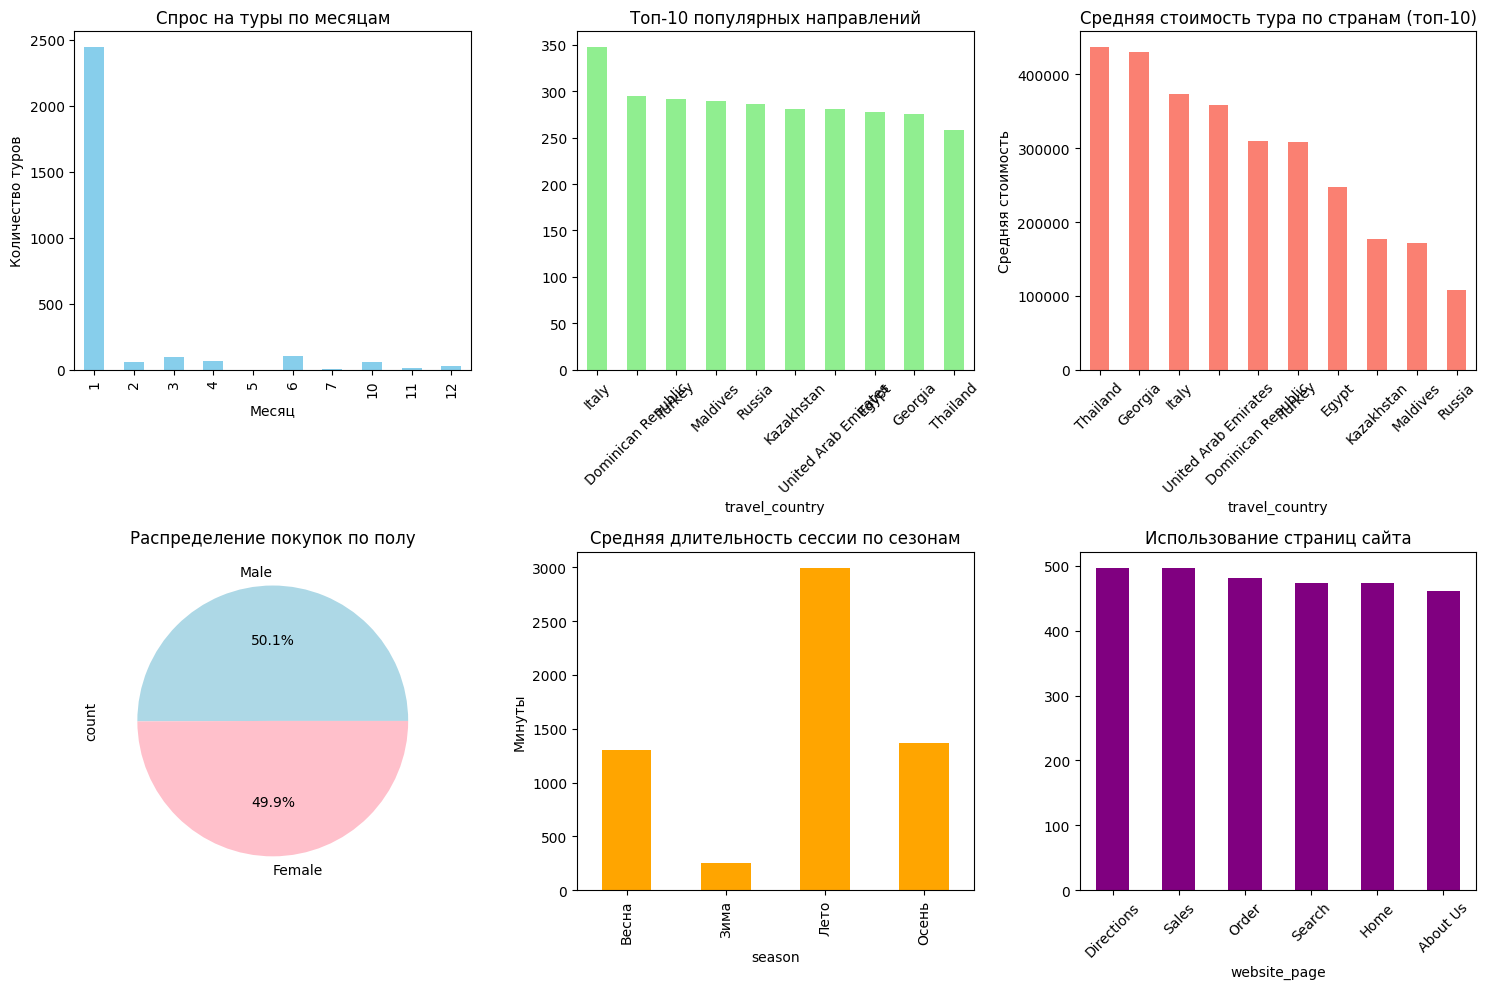

In [19]:
plt.figure(figsize=(15, 10))

#Спрос по месяцам
plt.subplot(2, 3, 1)
monthly_demand.plot(kind='bar', color='skyblue')
plt.title('Спрос на туры по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество туров')

#Популярность стран
plt.subplot(2, 3, 2)
df['travel_country'].value_counts().head(10).plot(kind='bar', color='lightgreen')
plt.title('Топ-10 популярных направлений')
plt.xticks(rotation=45)

#Стоимость туров по странам
plt.subplot(2, 3, 3)
avg_price_by_country.head(10).plot(kind='bar', color='salmon')
plt.title('Средняя стоимость тура по странам (топ-10)')
plt.xticks(rotation=45)
plt.ylabel('Средняя стоимость')

#Зависимость от пола
plt.subplot(2, 3, 4)
gender_purchases.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'pink'])
plt.title('Распределение покупок по полу')

#Длительность сессий по сезонам
plt.subplot(2, 3, 5)
seasonal_duration.plot(kind='bar', color='orange')
plt.title('Средняя длительность сессии по сезонам')
plt.ylabel('Минуты')

#Используемые страницы сайта
plt.subplot(2, 3, 6)
df['website_page'].value_counts().plot(kind='bar', color='purple')
plt.title('Использование страниц сайта')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Проверка гипотез

##1.   Нулевая гипотеза (H0): Мужчины и женщины покупают туры одинаково часто
##2.   Альтернативная гипотеза (H1): Мужчины покупают туры чаще, чем женщины



In [20]:
male_data = df[df['sex'] == 'Male']
female_data = df[df['sex'] == 'Female']

print(f"Общее количество наблюдений: {len(df)}")
print(f"Мужчины: {len(male_data)} наблюдений")
print(f"Женщины: {len(female_data)} наблюдений")

contingency_table = pd.crosstab(df['sex'], columns='count')
print("Таблица частот:")
print(contingency_table)

# Проверяем нормальность распределения
print("Проверка нормальности распределения:")
male_count = len(male_data)
female_count = len(female_data)
total_count = len(df)

print(f"Доля мужчин: {male_count/total_count:.3f} ({male_count}/{total_count})")
print(f"Доля женщин: {female_count/total_count:.3f} ({female_count}/{total_count})")

# Z-тест для пропорций
from statsmodels.stats.proportion import proportions_ztest

# Подготовка данных для z-теста
count = [male_count, female_count]
nobs = [total_count, total_count]

# Двусторонний z-тест
z_stat, p_value = proportions_ztest(count, nobs)
print("\nZ-тест для пропорций:")
print(f"Z-статистика: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Односторонний тест (мужчины > женщины)
z_stat_one_sided, p_value_one_sided = proportions_ztest([male_count, female_count], [total_count, total_count], alternative='larger')
print("Односторонний Z-тест (мужчины > женщины):")
print(f"Z-статистика: {z_stat_one_sided:.4f}")
print(f"P-value: {p_value_one_sided:.4f}")

# Критическое значение Z для alpha = 0.05
z_critical = stats.norm.ppf(0.95)
print(f"Критическое значение Z (alpha=0.05): {z_critical:.4f}")

alpha = 0.05
print("\nРезультат теста:")
if p_value_one_sided < alpha:
    print("Отвергаем нулевую гипотезу")
    print("Статистически значимые данные свидетельствуют, что мужчины покупают туры чаще, чем женщины")
else:
    print("Не отвергаем нулевую гипотезу")
    print("Нет статистически значимых доказательств, что мужчины покупают туры чаще женщин")

print(f"Уровень значимости: alpha = {alpha}")
print(f"P-value: {p_value_one_sided:.4f}")

Общее количество наблюдений: 2881
Мужчины: 1442 наблюдений
Женщины: 1439 наблюдений
Таблица частот:
col_0   count
sex          
Female   1439
Male     1442
Проверка нормальности распределения:
Доля мужчин: 0.501 (1442/2881)
Доля женщин: 0.499 (1439/2881)

Z-тест для пропорций:
Z-статистика: 0.0790
P-value: 0.9370
Односторонний Z-тест (мужчины > женщины):
Z-статистика: 0.0790
P-value: 0.4685
Критическое значение Z (alpha=0.05): 1.6449

Результат теста:
Не отвергаем нулевую гипотезу
Нет статистически значимых доказательств, что мужчины покупают туры чаще женщин
Уровень значимости: alpha = 0.05
P-value: 0.4685




##1.   Нулевая гипотеза (H0): Мужчины и женщины покупают туры одинаковой стоимости
##2.   Альтернативная гипотеза (H1): Мужчины покупают более дорогие туры, чем женщины



In [21]:
print("Статистика по стоимости туров:")
print("Мужчины:")
print(f"  Среднее: {male_data['travel_amount'].mean():.2f}")
print(f"  Стандартное отклонение: {male_data['travel_amount'].std():.2f}")
print(f"  Медиана: {male_data['travel_amount'].median():.2f}")

print("\nЖенщины:")
print(f"  Среднее: {female_data['travel_amount'].mean():.2f}")
print(f"  Стандартное отклонение: {female_data['travel_amount'].std():.2f}")
print(f"  Медиана: {female_data['travel_amount'].median():.2f}")

# Проверка нормальности распределения (тест Шапиро-Уилка)
print("\nПроверка нормальности распределения:")
shapiro_male = stats.shapiro(male_data['travel_amount'])
shapiro_female = stats.shapiro(female_data['travel_amount'])

print(f"Мужчины - W: {shapiro_male[0]:.4f}, p-value: {shapiro_male[1]:.4f}")
print(f"Женщины - W: {shapiro_female[0]:.4f}, p-value: {shapiro_female[1]:.4f}")

# Проверка равенства дисперсий (тест Левена)
levene_test = stats.levene(male_data['travel_amount'], female_data['travel_amount'])
print("\nТест Левена на равенство дисперсий:")
print(f"F-статистика: {levene_test[0]:.4f}, p-value: {levene_test[1]:.4f}")

# T-тест для независимых выборок
# Используем ttest_ind с equal_var=False из-за вероятного неравенства дисперсий
t_stat, p_value_t = stats.ttest_ind(male_data['travel_amount'], female_data['travel_amount'], equal_var=False, alternative='greater')  # односторонний тест

print(f"\nT-тест для независимых выборок (односторонний):")
print(f"T-статистика: {t_stat:.4f}")
print(f"P-value: {p_value_t:.4f}")
print(f"Степени свободы: {len(male_data) + len(female_data) - 2}")

# Критическое значение t для alpha = 0.05
t_critical = stats.t.ppf(0.95, len(male_data) + len(female_data) - 2)
print(f"Критическое значение t (alpha=0.05): {t_critical:.4f}")

# Непараметрический тест (Манна-Уитни) как дополнительная проверка
mannwhitney = stats.mannwhitneyu(male_data['travel_amount'],
                                female_data['travel_amount'],
                                alternative='greater')
print("\nU-тест Манна-Уитни (односторонний):")
print(f"U-статистика: {mannwhitney[0]:.4f}")
print(f"P-value: {mannwhitney[1]:.4f}")

# Вывод по второму тесту
print(f"\nРезультат теста:")
if p_value_t < alpha:
    print("Отвергаем нулевую гипотезу")
    print("Статистически значимые данные свидетельствуют, что мужчины покупают БОЛЕЕ ДОРОГИЕ туры")
else:
    print("Не отвергаем нулевую гипотезу")
    print("Нет статистически значимых доказательств, что мужчины покупают более дорогие туры")

print(f"Уровень значимости: alpha = {alpha}")
print(f"P-value: {p_value_t:.4f}")

Статистика по стоимости туров:
Мужчины:
  Среднее: 293846.67
  Стандартное отклонение: 191150.32
  Медиана: 255500.00

Женщины:
  Среднее: 289627.40
  Стандартное отклонение: 186909.93
  Медиана: 249600.00

Проверка нормальности распределения:
Мужчины - W: 0.9254, p-value: 0.0000
Женщины - W: 0.9286, p-value: 0.0000

Тест Левена на равенство дисперсий:
F-статистика: 0.1633, p-value: 0.6862

T-тест для независимых выборок (односторонний):
T-статистика: 0.5990
P-value: 0.2746
Степени свободы: 2879
Критическое значение t (alpha=0.05): 1.6454

U-тест Манна-Уитни (односторонний):
U-статистика: 1047363.5000
P-value: 0.3296

Результат теста:
Не отвергаем нулевую гипотезу
Нет статистически значимых доказательств, что мужчины покупают более дорогие туры
Уровень значимости: alpha = 0.05
P-value: 0.2746


##+Средняя длительность консультации

In [22]:
con_dur = df[df['consultation'] == True]
no_con = df[df['consultation'] == False]

In [23]:
avg_cons_duration = con_dur['cons_duration (min)'].mean()
print(f"Средняя длительность консультации: {avg_cons_duration:.2f} минут")

max_cons_duration = con_dur['cons_duration (min)'].max()
print(f"Максимальная длительность консультации: {max_cons_duration:.2f} минуты")

min_cons_duration = con_dur['cons_duration (min)'].min()
print(f"Минимальная длительность консультации: {min_cons_duration:.2f} минуту")

median_cons_duration = con_dur['cons_duration (min)'].median()
print(f"Медианная длительность консультации: {median_cons_duration:.2f} минут")

Средняя длительность консультации: 82.27 минут
Максимальная длительность консультации: 523.00 минуты
Минимальная длительность консультации: 1.00 минуту
Медианная длительность консультации: 45.00 минут


СТАТИСТИКА КОНСУЛЬТАЦИЙ ПО МЕСЯЦАМ
Всего консультаций: 203
Всего месяцев в анализируемом периоде: 12
Месяцев с консультациями: 10
Месяцев без консультаций: 2
 
В разбивке по месяцам:
 Январь: 3 консультаций
 Февраль: 29 консультаций
 Март: 45 консультаций
 Апрель: 30 консультаций
 Май: 1 консультаций
 Июнь: 45 консультаций
 Июль: 6 консультаций
 Август: 0 консультаций
 Сентябрь: 0 консультаций
 Октябрь: 22 консультаций
 Ноябрь: 7 консультаций
 Декабрь: 15 консультаций


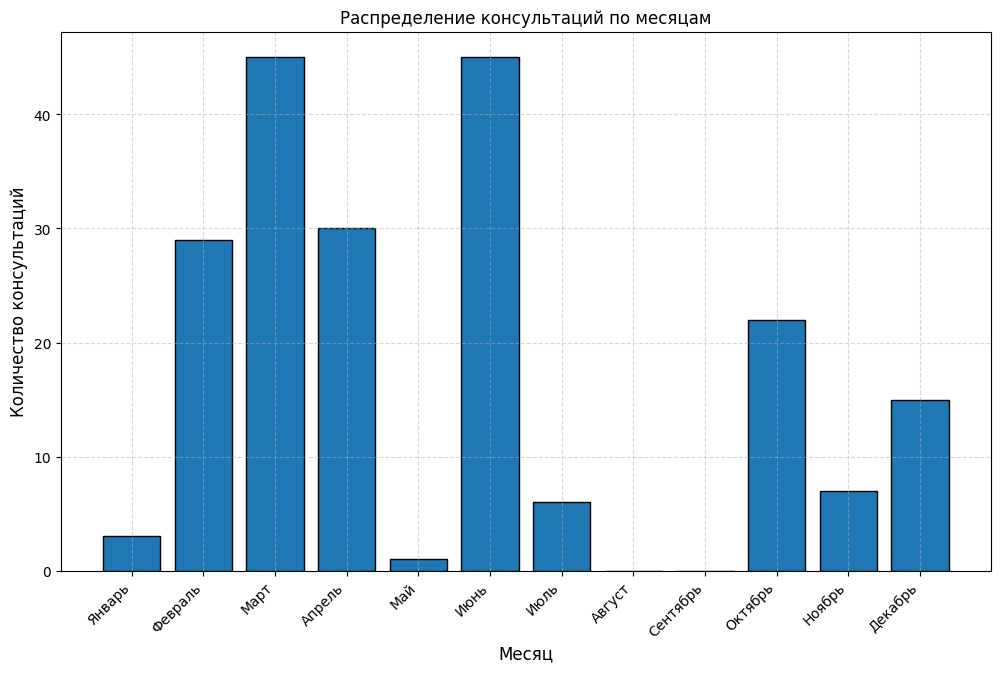

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df['start_session'] = pd.to_datetime(df['start_session'])
df['month'] = df['start_session'].dt.to_period('M')
consultations = df[df['consultation'] == True]

min_date = df['start_session'].min()
max_date = df['start_session'].max()
all_months = pd.period_range(start=min_date, end=max_date, freq='M')

monthly_consultations = consultations.groupby('month').size()
monthly_consultations = monthly_consultations.reindex(all_months, fill_value=0)

bukva_months = {
    1: 'Январь', 2: 'Февраль', 3: 'Март', 4: 'Апрель',
    5: 'Май', 6: 'Июнь', 7: 'Июль', 8: 'Август',
    9: 'Сентябрь', 10: 'Октябрь', 11: 'Ноябрь', 12: 'Декабрь'
}

month_labels = []
month_details = []

for period in monthly_consultations.index:
    month_num = period.month
    month_name = bukva_months.get(month_num, f'Месяц {month_num}')
    month_labels.append(f"{month_name}")
    month_details.append((f"{month_name}", monthly_consultations[period]))

plt.figure(figsize=(12, 7))
bars = plt.bar(range(len(monthly_consultations)), monthly_consultations.values, edgecolor='black')
plt.title('Распределение консультаций по месяцам')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество консультаций', fontsize=12)
plt.xticks(range(len(monthly_consultations)), month_labels, rotation=45, ha='right')
plt.grid(linestyle='--', alpha=0.5)

print("СТАТИСТИКА КОНСУЛЬТАЦИЙ ПО МЕСЯЦАМ")
print(f"Всего консультаций: {consultations.shape[0]}")
print(f"Всего месяцев в анализируемом периоде: {len(monthly_consultations)}")
print(f"Месяцев с консультациями: {len(monthly_consultations[monthly_consultations > 0])}")
print(f"Месяцев без консультаций: {len(monthly_consultations[monthly_consultations == 0])}")

print(" \nВ разбивке по месяцам:")
for month_label, count in month_details:
    print(f" {month_label}: {count} консультаций")

## Нулевая гипотеза (Н0): средняя сумма заказа с консультацией равна сумме заказа без консультации

Альтернативная гипотеза (Н1): средняя сумма заказа при наличии консультации ниже, чем без нее

In [25]:
import scipy.stats as st

In [26]:
# Разделяем на две группы: с консультацией и без
consult_true = df[df['consultation'] == True]['travel_amount']
consult_false = df[df['consultation'] == False]['travel_amount']

print(f"Количество покупок туров с консультацией: {len(consult_true)}")
print(f"Количество покупок туров  без консультации: {len(consult_false)}")

Количество покупок туров с консультацией: 203
Количество покупок туров  без консультации: 2678


**Видим, что туры покупаются в преобладающем количестве без консультации** (Количество покупок туров с консультацией: 203, без - 2678)

In [27]:
var_consult_true = consult_true.var()
var_consult_false = consult_false.var()

print(f'Дисперсия суммы с консультацией: {var_consult_true:.2f}')
print(f'Дисперсия суммы без консультации: {var_consult_false:.2f}')
print(f'Отношение дисперсий: {var_consult_true/var_consult_false:.2f}')

Дисперсия суммы с консультацией: 29862479020.57
Дисперсия суммы без консультации: 36038958183.58
Отношение дисперсий: 0.83


In [28]:
results = st.ttest_ind(consult_true, consult_false,
                       equal_var=False,  # дисперсии разные
                       alternative='less')  # односторонний тест: mean(consult_true) < mean(consult_false)

print(f'Средняя сумма заказа с консультацией: {consult_true.mean():.2f}')
print(f'Средняя сумма заказа без консультации: {consult_false.mean():.2f}')
print(f'Разница: {consult_false.mean() - consult_true.mean():.2f}')
print(f't-статистика: {results.statistic:.4f}')
print(f'p-value: {results.pvalue:.6f}')

Средняя сумма заказа с консультацией: 249307.23
Средняя сумма заказа без консультации: 294955.70
Разница: 45648.47
t-статистика: -3.6025
p-value: 0.000191


In [29]:
alpha = 0.05

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу: Средняя сумма заказа при наличии консультации СТАТИСТИЧЕСКИ ЗНАЧИМО НИЖЕ, чем без нее')
else:
    print('Нет оснований отвергнуть нулевую гипотезу: Нет статистически значимых различий в средней сумме заказа')

Отвергаем нулевую гипотезу: Средняя сумма заказа при наличии консультации СТАТИСТИЧЕСКИ ЗНАЧИМО НИЖЕ, чем без нее


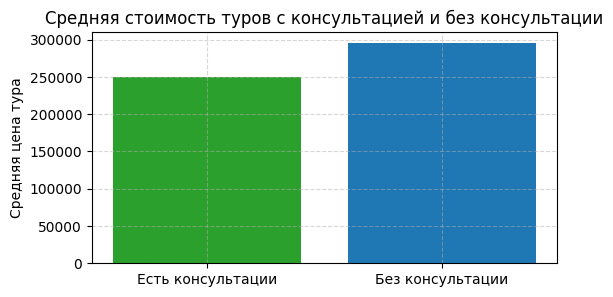

In [30]:
name = 'consultation'
ticks = ['Есть консультации', 'Без консультации']

data = df.groupby(name).agg({'travel_amount': 'mean'}).reset_index()
data = data.sort_values(name, ascending=False)

bar_colors = ['tab:green', 'tab:blue']
plt.figure(figsize=(6,3))
plt.bar(ticks, data['travel_amount'], color=bar_colors)
plt.xlabel('')
plt.ylabel('Средняя цена тура')
plt.title('Средняя стоимость туров с консультацией и без консультации')
plt.grid(linestyle='--', alpha=0.5)
plt.show()

## Нулевая гипотеза (Н0): среднее количество клиентов, которые оформили заказ самостоятельно и тех, кто обратился за помощью к консультанту, равно

Альтернативная гипотеза (Н1): среднее количество клиентов, которые оформили заказ самостоятельно выше, чем тех, кто обратился за помощью к консультанту



Мы знаем, что пропусков значений у нас нет. В датасете представлена информация только по тем клиента, которые оформили тур. Следовательно, количество туров = количеству клиентов и мы можем воспользоваться

In [31]:
# Разделяем на две группы: с консультацией и без
cons_true_clients = df[df['consultation'] == True]['id']
cons_false_clients = df[df['consultation'] == False]['id']

print(f"Количество клиентов, оформивших туры с консультацией: {len(cons_true_clients)}")
print(f"Количество клиентов, оформивших туры  без консультации: {len(cons_false_clients)}")

Количество клиентов, оформивших туры с консультацией: 203
Количество клиентов, оформивших туры  без консультации: 2678


In [32]:
var_cons_true = cons_true_clients.var()
var_cons_false = cons_false_clients.var()

print(f'Дисперсия клиентов с консультацией: {var_consult_true:.2f}')
print(f'Дисперсия клиентов без консультации: {var_consult_false:.2f}')
print(f'Отношение дисперсий: {var_consult_true/var_consult_false:.2f}')

Дисперсия клиентов с консультацией: 29862479020.57
Дисперсия клиентов без консультации: 36038958183.58
Отношение дисперсий: 0.83


In [33]:
results = st.ttest_ind(cons_true_clients, cons_false_clients,
                       equal_var=False,  # дисперсии разные
                       alternative='less')  # односторонний тест: mean(consult_true) < mean(consult_false)

print(f'Среднее количество клиентов, оформивших туры с консультацией: {cons_true_clients.mean():.2f}')
print(f'Среднее количество клиентов, оформивших туры  без консультации: {cons_false_clients.mean():.2f}')
print(f'Разница: {cons_false_clients.mean() - cons_true_clients.mean():.2f}')
print(f't-статистика: {results.statistic:.4f}')
print(f'p-value: {results.pvalue:.6f}')

Среднее количество клиентов, оформивших туры с консультацией: 472.32
Среднее количество клиентов, оформивших туры  без консультации: 504.68
Разница: 32.36
t-статистика: -1.4783
p-value: 0.070348


In [34]:
alpha = 0.05

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу: среднее количество клиентов, оформивших туры с консультацией, СТАТИСТИЧЕСКИ ЗНАЧИМО НИЖЕ, чем без нее')
else:
    print('Нет оснований отвергнуть нулевую гипотезу: Нет статистически значимых различий в количестве клиентов из обеих групп')

Нет оснований отвергнуть нулевую гипотезу: Нет статистически значимых различий в количестве клиентов из обеих групп


## Нулевая гипотеза (Н0): стоимость тура зависит от сезона

Альтернативная гипотеза (Н1): стоимость тура не зависит от сезона

In [35]:
df['start_session'] = pd.to_datetime(df['start_session'])

def get_season(dt):
    m = dt.month
    if m in [12, 1, 2]:
        return 'Winter'
    elif m in [3, 4, 5]:
        return 'Spring'
    elif m in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['start_session'].apply(get_season)
df['season'] = df['season'].astype('category')


In [36]:
import scipy.stats as stats

groups_price = [group["travel_amount"].values for _, group in df.groupby("season")]

f_stat, p_value = stats.f_oneway(*groups_price)

print("ANOVA — влияние сезона на стоимость тура")
print("F:", f_stat, "| p-value:", p_value)

if p_value < 0.05:
    print("❗️Стоимость тура статистически зависит от сезона.")
else:
    print("Стоимость тура НЕ показывает статистически значимой зависимости от сезона.")

ANOVA — влияние сезона на стоимость тура
F: 2.3629117120289425 | p-value: 0.06935276789015143
Стоимость тура НЕ показывает статистически значимой зависимости от сезона.


<Figure size 800x500 with 0 Axes>

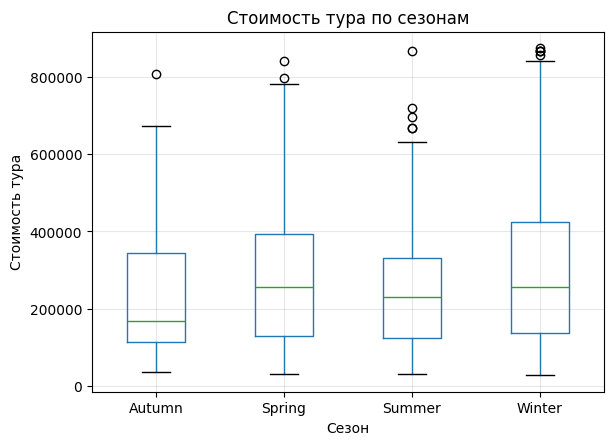

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df.boxplot(column="travel_amount", by="season")
plt.title("Стоимость тура по сезонам")
plt.suptitle("")
plt.xlabel("Сезон")
plt.ylabel("Стоимость тура")
plt.grid(True, alpha=0.3)
plt.show()


## Нулевая гипотеза (Н0): количество человек, на которых оформляется тур, зависит от сезона

Альтернативная гипотеза (Н1): количество человек, на которых оформляется тур, не зависит от сезона


In [42]:
groups_people = [group["number_of_travalers"].values for _, group in df.groupby("season")]

f_stat, p_value = stats.f_oneway(*groups_people)

print("ANOVA — влияние сезона на количество людей")
print("F:", f_stat, "| p-value:", p_value)

if p_value < 0.05:
    print("❗️Количество людей статистически зависит от сезона.")
else:
    print("Количество людей НЕ показывает статистически значимой зависимости от сезона.")


ANOVA — влияние сезона на количество людей
F: 1.0732717326899235 | p-value: 0.3591373650817386
Количество людей НЕ показывает статистически значимой зависимости от сезона.


<Figure size 800x500 with 0 Axes>

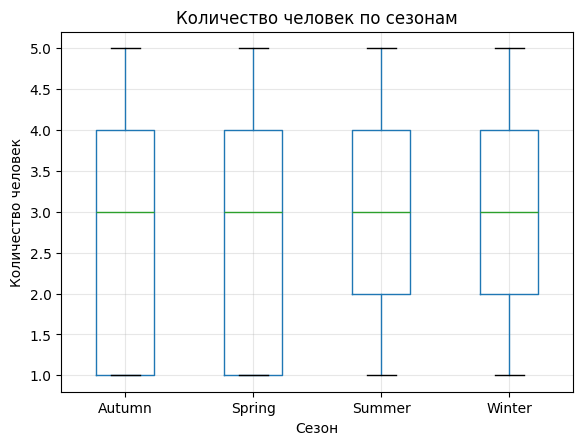

In [43]:
plt.figure(figsize=(8, 5))
df.boxplot(column="number_of_travalers", by="season")
plt.title("Количество человек по сезонам")
plt.suptitle("")
plt.xlabel("Сезон")
plt.ylabel("Количество человек")
plt.grid(True, alpha=0.3)
plt.show()


#Помощь пользователям

##Количество операторов, необходимое для обслуживани клиентов в пиковые даты

ТОП-3 пиковых дня по количеству консультаций:
1. 2024-07-01: 5 консультаций
2. 2024-02-03: 4 консультаций
3. 2024-02-10: 4 консультаций
Анализ самого загруженного дня: 2024-07-01
   Всего консультаций: 5
Распределение консультаций по часам:
hour
5     2
7     1
13    1
16    1
dtype: int64
Самый загруженный час: 5:00
   Консультаций в этот час: 2
Анализ перекрытия консультаций за весь день 2024-07-01:
   Максимальное одновременных консультаций: 1
   Время пиковой нагрузки: 2024-07-01 05:39:36
Анализ перекрытия консультаций в пиковый час (5:00):
   Максимальное одновременных консультаций: 1
   Время пиковой нагрузки в этот час: 2024-07-01 05:39:36
Параметры для расчета:
  • Заявок в пиковый час: 2
  • Средняя длительность консультации: 35.4 мин
  • Производительность оператора: 1.7 конс./час

Высокий уровень сервиса:
  • Макс. время ожидания: 1 мин
  • Уровень обслуживания: 90.0%
  • Необходимо операторов: 5

Стандартный уровень:
  • Макс. время ожидания: 3 мин
  • Уровень обслуживания:

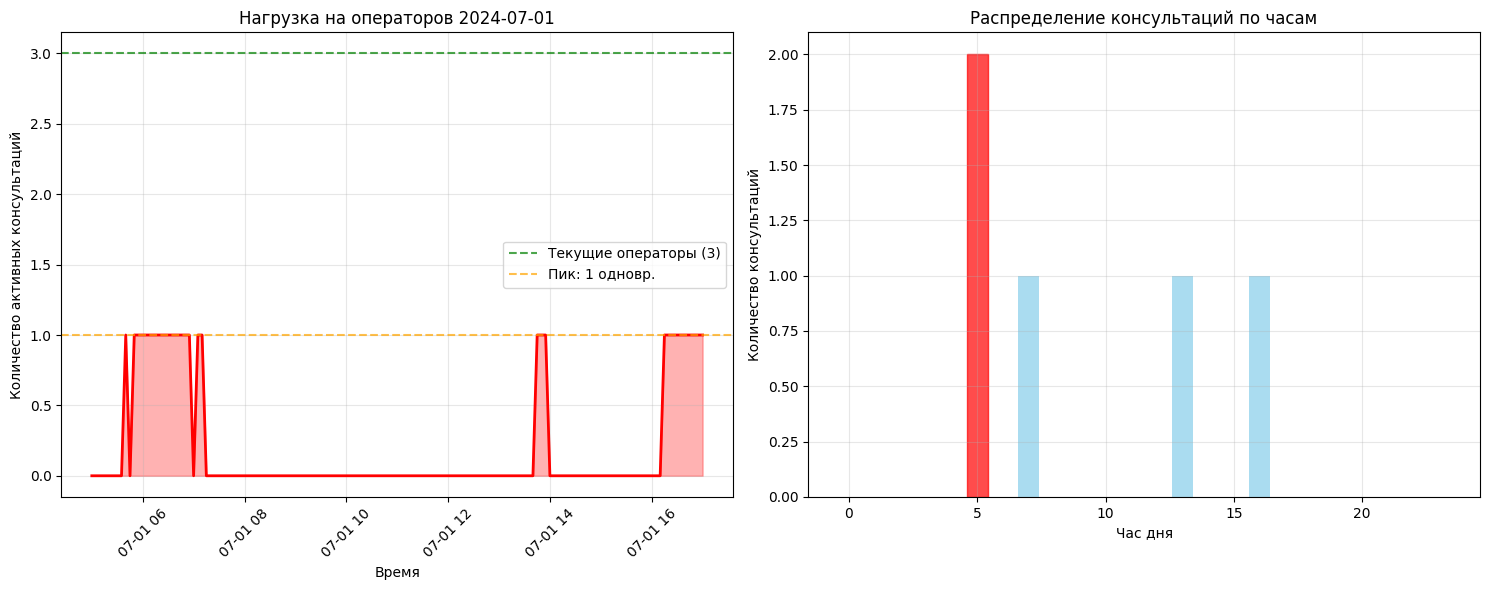

Текущее количество операторов: 3
Максимальная одновременная нагрузка: 1

Рекомендуемое количество операторов в пиковые часы: 4
Это обеспечит:
  ✓ Обслуживание всех клиентов без очереди
  ✓ Запас мощности: 3 оператора
Средний чек: 322907 руб
Потенциально потерянные продажи в пик: 0 руб/час
Стоимость доп. операторов: 2500 руб/день

Окупаемость: inf дней (при 8-часовом рабочем дне)


In [38]:
consultation_df = df[df['consultation'] == True].copy()
daily_consultations = consultation_df.groupby(consultation_df['start_session'].dt.date).size()
peak_days = daily_consultations.nlargest(3)

print("ТОП-3 пиковых дня по количеству консультаций:")
for i, (date, count) in enumerate(peak_days.items(), 1):
    print(f"{i}. {date}: {count} консультаций")

peak_date = peak_days.index[0]
peak_day_data = consultation_df[consultation_df['start_session'].dt.date == peak_date].copy()

print(f"Анализ самого загруженного дня: {peak_date}")
print(f"   Всего консультаций: {len(peak_day_data)}")

peak_day_data['hour'] = peak_day_data['start_session'].dt.hour
hourly_distribution = peak_day_data.groupby('hour').size()

print(f"Распределение консультаций по часам:")
print(hourly_distribution)

peak_hour = hourly_distribution.idxmax()
peak_hour_data = peak_day_data[peak_day_data['hour'] == peak_hour]

print(f"Самый загруженный час: {peak_hour}:00")
print(f"   Консультаций в этот час: {len(peak_hour_data)}")

def calculate_concurrent_sessions(data, time_window_minutes=1):
    """Рассчитывает максимальное количество одновременных консультаций"""
    times = []

    for _, row in data.iterrows():
        start = row['start_session']
        duration = row['cons_duration (min)'] if row['cons_duration (min)'] > 0 else 5  # если 0, берем 5 мин как минимум
        end = start + timedelta(minutes=duration)
        times.append((start, 'start'))
        times.append((end, 'end'))

    times.sort()
    concurrent = 0
    max_concurrent = 0
    max_time = None

    for time, event_type in times:
        if event_type == 'start':
            concurrent += 1
            if concurrent > max_concurrent:
                max_concurrent = concurrent
                max_time = time
        else:
            concurrent -= 1

    return max_concurrent, max_time

max_concurrent_day, peak_time_day = calculate_concurrent_sessions(peak_day_data)
print(f"Анализ перекрытия консультаций за весь день {peak_date}:")
print(f"   Максимальное одновременных консультаций: {max_concurrent_day}")
print(f"   Время пиковой нагрузки: {peak_time_day}")

peak_hour_start = peak_day_data[peak_day_data['hour'] == peak_hour]['start_session'].min()
peak_hour_end = peak_hour_start.replace(hour=peak_hour, minute=0) + timedelta(hours=1)
peak_hour_sessions = peak_day_data[
    (peak_day_data['start_session'] >= peak_hour_start.replace(minute=0, second=0)) &
    (peak_day_data['start_session'] < peak_hour_start.replace(minute=0, second=0) + timedelta(hours=1))]

max_concurrent_hour, peak_time_hour = calculate_concurrent_sessions(peak_hour_sessions)
print(f"Анализ перекрытия консультаций в пиковый час ({peak_hour}:00):")
print(f"   Максимальное одновременных консультаций: {max_concurrent_hour}")
print(f"   Время пиковой нагрузки в этот час: {peak_time_hour}")

def calculate_operators_needed(arrival_rate, service_rate, target_wait_time=1, service_level=0.8):
  lambda_val = arrival_rate / 60
  mu = service_rate / 60
  operators = 1
  while True:
    rho = lambda_val / (operators * mu)
    if rho >= 1:
        operators += 1
        continue
    P_wait = rho ** operators
    if operators == 1:
        W_q = (rho ** 2) / (lambda_val * (1 - rho))
    else:
        W_q = (rho ** operators) / (operators * mu * (1 - rho) * (1 - rho ** (operators - 1)))
    if P_wait < (1 - service_level) and W_q * 60 < target_wait_time:
        break
    operators += 1
    if operators > 50:
        break
  return operators

peak_hour_arrivals = len(peak_hour_sessions)
avg_consult_duration = peak_day_data['cons_duration (min)'].mean()
service_rate_per_operator = 60 / avg_consult_duration

print(f"Параметры для расчета:")
print(f"  • Заявок в пиковый час: {peak_hour_arrivals}")
print(f"  • Средняя длительность консультации: {avg_consult_duration:.1f} мин")
print(f"  • Производительность оператора: {service_rate_per_operator:.1f} конс./час")

scenarios = [
    {"name": "Высокий уровень сервиса", "wait_time": 1, "service_level": 0.9},
    {"name": "Стандартный уровень", "wait_time": 3, "service_level": 0.8},
    {"name": "Экономичный вариант", "wait_time": 5, "service_level": 0.7},]

for scenario in scenarios:
    operators_needed = calculate_operators_needed(
        arrival_rate=peak_hour_arrivals,
        service_rate=service_rate_per_operator,
        target_wait_time=scenario["wait_time"],
        service_level=scenario["service_level"])

    print(f"\n{scenario['name']}:")
    print(f"  • Макс. время ожидания: {scenario['wait_time']} мин")
    print(f"  • Уровень обслуживания: {scenario['service_level']*100}%")
    print(f"  • Необходимо операторов: {operators_needed}")

time_slots = pd.date_range(
    start=peak_day_data['start_session'].min().floor('H'),
    end=peak_day_data['start_session'].max().ceil('H'),
    freq='5min')

active_sessions = []

for slot in time_slots:
    active = 0
    for _, row in peak_day_data.iterrows():
        start = row['start_session']
        duration = row['cons_duration (min)'] if row['cons_duration (min)'] > 0 else 5
        end = start + timedelta(minutes=duration)
        if start <= slot < end:
            active += 1
    active_sessions.append(active)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(time_slots, active_sessions, color='red', linewidth=2)
plt.axhline(y=3, color='green', linestyle='--', alpha=0.7, label='Текущие операторы (3)')
plt.axhline(y=max_concurrent_day, color='orange', linestyle='--', alpha=0.7,
           label=f'Пик: {max_concurrent_day} одновр.')
plt.fill_between(time_slots, active_sessions, alpha=0.3, color='red')
plt.title(f'Нагрузка на операторов {peak_date}')
plt.xlabel('Время')
plt.ylabel('Количество активных консультаций')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
hours = list(range(24))
consultations_by_hour = [peak_day_data[peak_day_data['hour'] == h].shape[0] for h in hours]
bars = plt.bar(hours, consultations_by_hour, color='skyblue', alpha=0.7)
bars[peak_hour].set_color('red')
plt.title('Распределение консультаций по часам')
plt.xlabel('Час дня')
plt.ylabel('Количество консультаций')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

current_operators = 3
recommended_operators = max(4, int(max_concurrent_hour * 1.2))
print(f"Текущее количество операторов: {current_operators}")
print(f"Максимальная одновременная нагрузка: {max_concurrent_hour}")
print(f"\nРекомендуемое количество операторов в пиковые часы: {recommended_operators}")
print(f"Это обеспечит:")

if recommended_operators >= max_concurrent_hour:
    print("  ✓ Обслуживание всех клиентов без очереди")
    print(f"  ✓ Запас мощности: {recommended_operators - max_concurrent_hour} оператора")
else:
    print("  ⚠ Часть клиентов будет ждать в очереди")

#Экономическа сторона вопроса
avg_ticket = peak_day_data['travel_amount'].mean()
potential_lost_sales = max(0, max_concurrent_hour - current_operators) * avg_ticket * 0.3
operator_salary = 50000  # руб/мес
additional_operators_cost = (recommended_operators - current_operators) * operator_salary / 20
print(f"Средний чек: {avg_ticket:.0f} руб")
print(f"Потенциально потерянные продажи в пик: {potential_lost_sales:.0f} руб/час")
print(f"Стоимость доп. операторов: {additional_operators_cost:.0f} руб/день")
print(f"\nОкупаемость: {additional_operators_cost / (potential_lost_sales/8):.1f} дней (при 8-часовом рабочем дне)")

#Матрица корреляции факторов, влияющих на стоимость тура

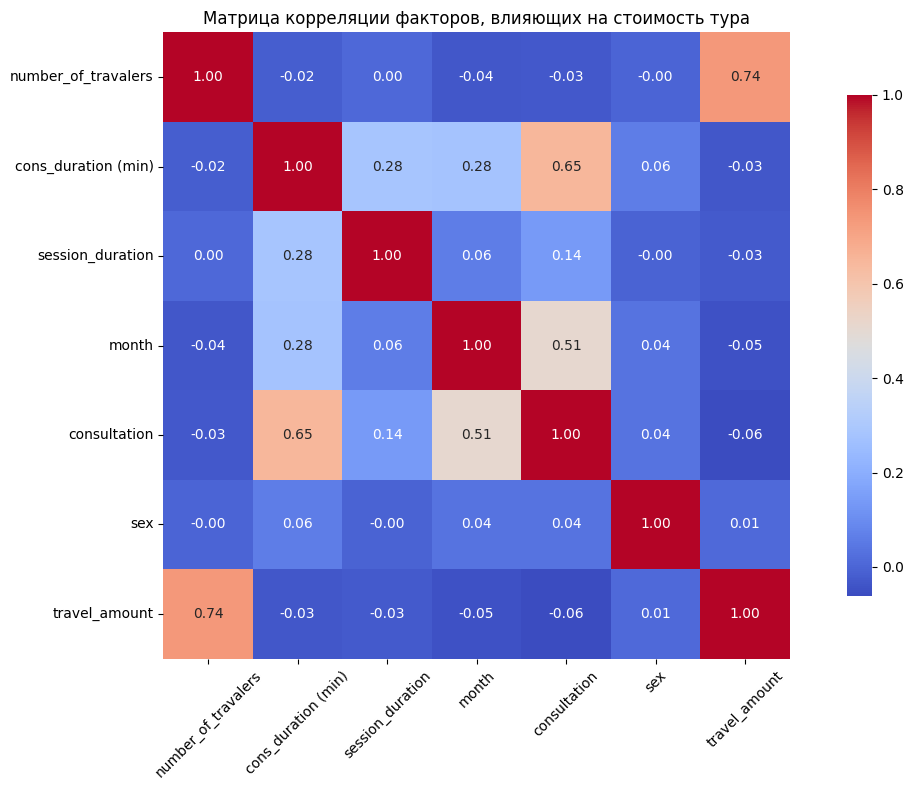

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

binary_cols = ['consultation', 'sex'] #преобразование бинарных и категориальных переменных
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({True: 1, False: 0, 'Male': 1, 'Female': 0})

if 'month' in df.columns: # преобразуем столбец 'month' в числовой формат (если он содержит Period объекты)
    if hasattr(df['month'], 'dt'):
        df['month'] = df['month'].dt.month
    else:
        df['month'] = pd.to_numeric(df['month'], errors='coerce')

numeric_cols = [
    'number_of_travalers',
    'cons_duration (min)',
    'session_duration',
    'month',
    'consultation',
    'sex',
    'travel_country_encoded',
    'website_page_encoded',
    'season_encoded',
    'travel_amount'
]

existing_numeric_cols = [col for col in numeric_cols if col in df.columns]
corr_df = df[existing_numeric_cols]
correlation_matrix = corr_df.corr(method='pearson')

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляции факторов, влияющих на стоимость тура')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



1. **Процесс оформления тура**

*   **Средняя длительность оформления**: 444.74 минут, то есть офрмление консультация в среднем длится **7,5 часов**, то есть примерно 1 рабочий
*   Средняя длительность оформления **по сезонам**:
Лето     2995.03 (49 часов)
Осень    1366.01 (22 часа)
Весна    1302.54 (21,7 часа)
Зима      247.92 (4 часа)
Дольше всего офрмляют тур летом, а меньше всего зимой. Возможно, зимний отдых в турагентстве плохо представлен, маленькая линейка и тогда можно рекомендовать увеличить количество предложений по зимнему отдыху


2. **Спрос на туры**

**по месяцам:**

*   больше всего = в январе (ранее бронирование? начинают заранее оформлять? ранее видели, что зимой очень быстро все оформляют.
*   значительно меньше во все другие месяцы (по мере убывания: июнь; февраль-март-апрель-октябрь);
*   самый маленький спрос: декабрь-ноябрь-июль-май

**все пиковые даты - в январе** (5 пиковых дат):

*   самые пиковые 21 января, 26 января,
*   просто пиковые 8 января, 27 января, 14 января

3. **Консультации**

**5 **пиковых** дней по спросу на консультации:**

*   1 июля, 3 февраля, 10 февраля, 7 марта, 3 апреля

Похоже, что сначала заранее (почти за год) консультируются, присматривают вариант, а потом в начале года оформляют тур

**Страницы, с которых чаще всего обращаются за консультациями**

*   Чаще всего - со страницы: 'Search'
*   Направления для путешествия
*   Домашняя страница
*   Скидки
*   Страница заказа
*   О нас - реже всего

**Доля самостоятельных оформлений по страницам:**

Чаще всего оформляют туры со следующих страниц:

*   О нас
*   Направления для путешествия
*   Домашняя страница
*   Заказ
*   Скидки
*   Поиск

По сайту турагентства можно сказать, что:

*   хорошо оформлена страница "О нас", видимо, создает доверительный образ, клиенты решаются оформить тур именно здесь, прочитав общую информацию
*   требует доработки страница с поиском тура, так как с нее реже всего оформляются и чаще всего возникают вопросы и запрос на консультацию
*   Скидки - не привлекают клиентов, мало оформлений с этой страницы и мало вопросов по ней возникает

4. **Страны**

Самые популярные страны по сезонам:

*   Зима: Italy
*   Весна: Kazakhstan
*   Лето: Italy
*   Осень: Maldives

Прослеживается логика: так как Италия - популярная страна для зимы и лета, а для поездки в Италию требуется виза, то клиенты пользуются консультацией, а также долго оформляют тур.
Но почему-то летом оформляют все равно дольше

5. Средняя стоимость:

Thailand                436451.02
Georgia                 430160.24
Italy                   373038.11
United Arab Emirates    357884.50
Dominican Republic      309265.06
Turkey                  308278.03
Egypt                   246917.15
Kazakhstan              176507.37
Maldives                171638.09
Russia                  107496.95


Мальдивы и Россия самые дешевые?

6. **Количество туристов**
Среднее количество человек в туре примерно 3 человека, то есть чаще покупают семейные туры

# Влияние внедрения самообучающегося чат-бота на нагрузку оператора\n\n## Изменение нагрузки на оператора\n\nПри внедрении самообучающегося чат-бота, который будет консультировать клиентов и подбирать для них туры, нагрузка на оператора изменится следующим образом:\n\n1. **Снижение базовой нагрузки**: Чат-бот будет обрабатывать большинство стандартных запросов клиентов, таких как подбор туров по предпочтениям, предоставление информации о доступных направлениях, ценах и условиях. Это позволит значительно снизить количество обращений к оператору.\n\n2. **Фильтрация запросов**: Чат-бот будет фильтровать запросы, передавая оператору только сложные случаи, требующие человеческого участия. Это повысит эффективность работы оператора, так как он будет заниматься исключительно сложными задачами.\n\n3. **Качество обслуживания**: Оператор сможет уделять больше времени каждому сложному запросу, что повысит качество обслуживания клиентов.\n\n4. **Снижение монотонной работы**: Исчезнет необходимость в повторении стандартных ответов, что сделает работу оператора более интересной и продуктивной.\n\n## Определение количества одновременно поддерживаемых сессий\n\nЧтобы определить количество одновременно поддерживаемых сессий, при котором вероятность вызова оператора составит 0.05, можно использовать модель теории массового обслуживания.\n\nПредположим, что:\n- λ — интенсивность поступления новых запросов\n- μ — интенсивность обслуживания одним ботом (количество запросов в единицу времени)\n- n — количество одновременно поддерживаемых сессий\n- P — вероятность вызова оператора (0.05)\n\nИспользуя формулу для вероятности отказа в системе M/M/n/n (формула Эрланга B):\n\n$$ B(n, \\lambda/\\mu) = \\frac{(\\lambda/\\mu)^n / n!}{\\sum_{k=0}^{n} (\\lambda/\\mu)^k / k!} $$\n\nгде B(n, A) — вероятность того, что все n каналов заняты, A = λ/μ — трафик в эрлангах.\n\nДля решения задачи необходимо:\n1. Оценить λ (интенсивность поступления запросов от клиентов)\n2. Оценить μ (скорость обработки запросов чат-ботом)\n3. Найти минимальное значение n, при котором B(n, A) ≤ 0.05\n\nПример расчета (гипотетический):\nДопустим, в среднем поступает 10 запросов в час (λ = 10/60 запросов в минуту), а бот обрабатывает 1 запрос за 5 минут в среднем (μ = 1/5 запросов в минуту).\nТогда A = λ/μ = (10/60)/(1/5) = 5/6 ≈ 0.83 эрланга\n\nДля A = 0.83, используя формулу Эрланга B:\n- При n=1: B(1, 0.83) ≈ 0.45\n- При n=2: B(2, 0.83) ≈ 0.15\n- При n=3: B(3, 0.83) ≈ 0.04\n\nТаким образом, при n=3 одновременно поддерживаемых сессиях вероятность вызова оператора будет примерно 0.04, что меньше требуемой 0.05.\n\n**Ответ: Для достижения вероятности вызова оператора 0.05 рекомендуется установить количество одновременно поддерживаемых сессий равным 3.**\n